# Stakes Group Analysis

Group-level Stakes review notebook. Load one or more cohorts, prepare the shared filtered view once, then plot a group summary + JND figure and the sound-ramp comparison using SEM across animals.

## 1. Setup

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "analysis" / "daily_merge.py").exists() and (candidate / "DataFiles").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find the Mafalda_analysis repo root from the current working directory."
    )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

ROOT

PosixPath('/Users/mafaldavalente/Documents/Mafalda_analysis')

## 2. Choose Cohorts

`DATASET_SELECTIONS` is the safest option when you want an explicit cohort subset. Set it to `None` to use all cohorts listed in `COHORTS`.

In [2]:
COHORTS = ["cohort2"]

# Explicit selections can list any subset of Stakes cohorts, e.g.:
# DATASET_SELECTIONS = ["cohort2"]
DATASET_SELECTIONS = None

## 3. Group Filter Settings

In [3]:
TRAINING_LEVEL = None
TRAINING_LEVEL_MAX = 16

## 4. Load Once, Prepare Once

In [4]:
from Pipeline.daily_plots import (
    load_stakes_group_data,
    prepare_stakes_group_data,
)
import Pipeline.biased_blocks as bb
import pandas as pd


def filter_group_review_rows(df):
    out = df.copy()
    session_type = pd.to_numeric(out.get("session_type"), errors="coerce")
    short_duration = pd.to_numeric(out.get("short_duration"), errors="coerce")

    keep_non_23 = ~session_type.eq(23)
    keep_23 = pd.Series(False, index=out.index, dtype=bool)
    type23 = out[session_type.eq(23)].copy()
    if not type23.empty:
        labeled_23 = bb.add_biased_block_condition(
            type23,
            biased_session_types=(23,),
            unbiased_rt_session_types=(),
            short_duration_value=None,
        )
        keep_23 = out.index.isin(labeled_23.index[labeled_23["block_condition"].eq("unbiased")])
    keep_23_like_rt_unbiased = keep_23 & short_duration.eq(0)
    return out[keep_non_23 | keep_23_like_rt_unbiased].copy()


df_raw, loaded_cohorts = load_stakes_group_data(
    cohorts=COHORTS,
    dataset_selections=DATASET_SELECTIONS,
)
df_group_input = filter_group_review_rows(df_raw)
group_prepared = prepare_stakes_group_data(
    df_group_input,
    training_level=TRAINING_LEVEL,
    training_level_max=TRAINING_LEVEL_MAX,
)

print("Loaded cohorts:", loaded_cohorts)
print(f"Raw rows: {len(df_raw)}")
print(f"Rows after session-23 unbiased-block RT filter: {len(df_group_input)}")
print(f"Prepared rows: {len(group_prepared['df'])}")
print(f"Animals: {group_prepared['info']['n_animals']}")
print(f"Sessions: {group_prepared['info']['n_sessions']}")
group_prepared['info']

[compute_jnd_by_ABL] Warning: no valid fits found.
[compute_jnd_by_ABL] Warning: no valid fits found.
[compute_jnd_by_ABL] Warning: no valid fits found.
[compute_jnd_by_ABL] Warning: no valid fits found.
[compute_jnd_by_ABL] Warning: no valid fits found.
[compute_jnd_by_ABL] Warning: no valid fits found.
[compute_jnd_by_ABL] Warning: no valid fits found.
[compute_jnd_by_ABL] Warning: no valid fits found.
[compute_jnd_by_ABL] Warning: no valid fits found.
[compute_jnd_by_ABL] Warning: no valid fits found.
Loaded cohorts: ['cohort2']
Raw rows: 17438
Rows after session-23 unbiased-block RT filter: 17438
Prepared rows: 15940
Animals: 10
Sessions: 60


{'line': ['Stakes'],
 'cohorts': ['cohort2'],
 'n_animals': 10,
 'animals': ['JCS0013',
  'JCS0014',
  'JCS0015',
  'JCS0016',
  'JCS0017',
  'JCS0018',
  'JCS0019',
  'JCS0020',
  'JCS0021',
  'JCS0022'],
 'n_sessions': 60,
 'n_trials': 15940}

## 5. Figure 1: Group Summary + JND

In [ ]:
import importlib
import matplotlib.pyplot as plt
import Pipeline.daily_plots as daily_plots

importlib.reload(daily_plots)
plt.close("all")

fig_group_daily = daily_plots.plot_stakes_group_summary_with_jnd(
    group_prepared,
    figsize=(10, 10),
)

## 6. Figure 2: Sound Ramp Comparison

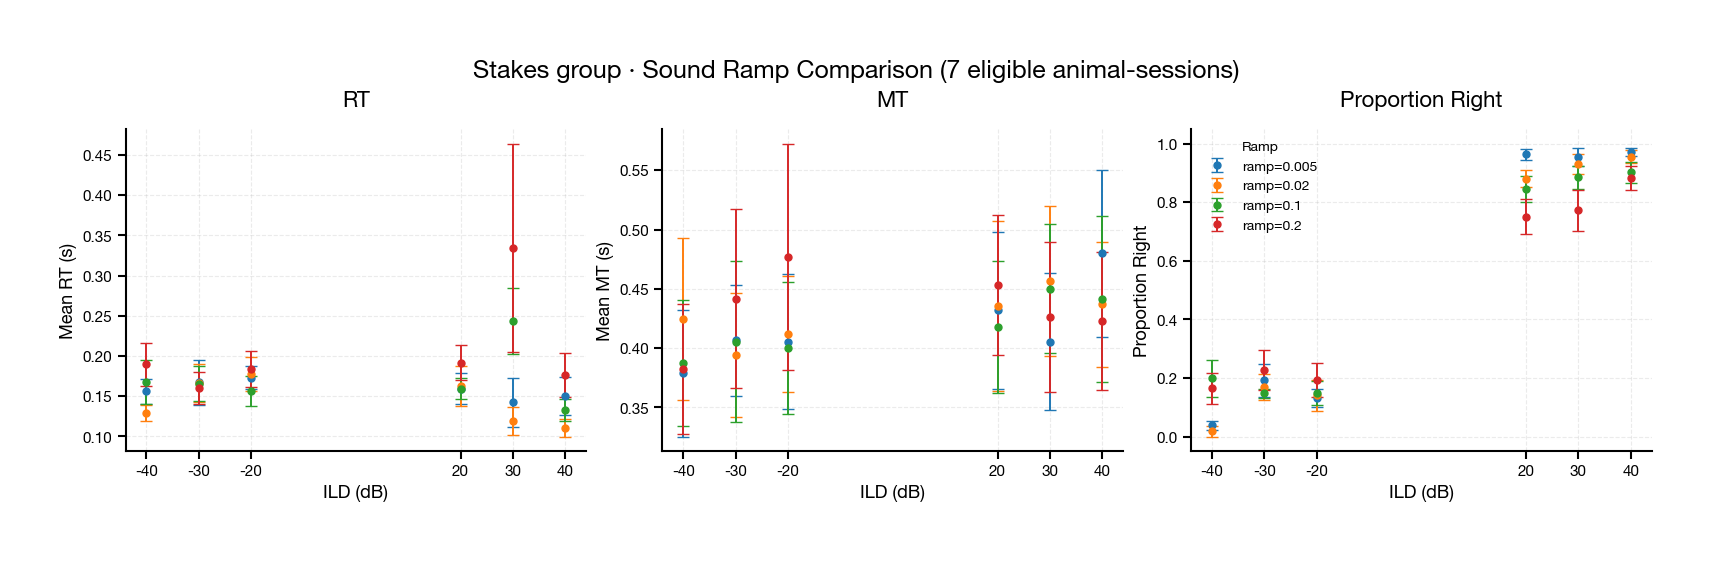

In [6]:
import importlib
import matplotlib.pyplot as plt
import Pipeline.daily_plots as daily_plots

importlib.reload(daily_plots)

fig_group_sound_ramp = daily_plots.plot_stakes_group_sound_ramp_comparison(
    group_prepared,
)